__If you are new to PheTK, please check out the APOE PheWAS - Logistic Regression notebook first.__

This notebook demonstrates how to run the same PheWAS pipeline in using dsub to schedule job on Google Cloud.

__Is there any advantage running PheTK using dsub compared to running directly in the notebook environment?__ 

_Yes, there are many advantages, including being able to select new computing hardware (vs being stuck with default hardware in the notebook), being able to scale up for large scale analyses (think hundreds or thousands of PheWAS runs or more), etc._

Often, users would run in dsub mode once they already have a working pipeline and already familiar with PheTK. While PheTK simplifies how to run PheWAS with dsub, users should learn to understand what happens behind the scene after a dsub job is submitted, how to monitor the jobs and how to potentially troubleshoot when there is any issue.

To learn more about dsub, users could look for _All of Us_ tutorial notebooks or check out their official GitHub repo at https://github.com/DataBiosphere/dsub.

In this notebook, we will run PheWAS with dsub using PheTK for the same workflow in the Logistic Regression notebook. The PheWAS analysis will be run on a Google Cloud machine configured with dsub.

## Initial setup

In [ ]:
!pip install phetk --upgrade

In [ ]:
!pip show PheTK | grep Version

__Please restart the notebook kernel before proceeding to the next step.__

In [1]:
from phetk.cohort import Cohort
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

import os

In [2]:
bucket = os.getenv("WORKSPACE_BUCKET")

## Preparing inputs for PheWAS with dsub

Note: since dsub requires inputs and outputs to be in a Google Cloud bucket, all the steps below will utilize Google Cloud bucket where applicable instead of local notebook storage.

For simplicity, the CLI version will be used to generate cohort, add covariates, and generate phecode counts, which will be used as input in PheWAS. All files will be saved in a bucket.

Here All of Us already created an environment variable named WORKSPACE_BUCKET storing the bucket address. We will use it and add some folder path after as desired.

In [ ]:
%%bash
# exit script if a command fails
set -e

# add phetk path if needed; this path is specific for this notebook environment.
export PATH=$PATH:/home/jupyter/.local/bin

# create cohort
echo "Creating cohort..."
echo
phetk cohort by-genotype \
--platform aou \
--aou_db_version 8 \
--chromosome_number 19 \
--genomic_position=44908684 \
--ref_allele T \
--alt_allele C \
--gt_dict '{"0": "0/0", "1":["0/1", "1/1"]}' \
--output_file_path "${WORKSPACE_BUCKET}/test/data/dsub__rs429358_cohort.tsv"

# add covariates
echo "Adding covariates..."
echo
phetk cohort add-covariates \
--cohort_file_path "${WORKSPACE_BUCKET}/test/data/dsub__rs429358_cohort.tsv" \
--age_at_last_ehr_event true \
--sex_at_birth true \
--first_n_pcs 5 \
--drop_nulls true \
--output_file_path "${WORKSPACE_BUCKET}/test/data/dsub__rs429358_cohort_with_covariates.tsv"

# generate phecode counts
echo "Generating phecode counts..."
echo
phetk phecode count-phecode \
--platform aou \
--phecode_version X \
--output_file_path "${WORKSPACE_BUCKET}/test/data/dsub__aou_phecode_counts.tsv"


The above cell output was cleared to avoid exposing sensitive information.

This cell output should look similar to the equivalent cells in the CLI example notebook.

## PheWAS with PheTK using dsub

In [4]:
# instantiate class PheWAS the same way as running in notebook, note that we need use the files in the bucket instead
phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path=f"{bucket}/test/data/dsub__aou_phecode_counts.tsv",
    cohort_file_path=f"{bucket}/test/data/dsub__rs429358_cohort_with_covariates.tsv",
    sex_at_birth_col="sex_at_birth",
    male_as_one=True,
    covariate_cols=[
        "age_at_last_ehr_event", "sex_at_birth",
        "pc1", "pc2", "pc3", "pc4", "pc5"
    ],
    independent_variable_of_interest="genotype",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path=f"{bucket}/test/results/dsub__rs429358_phewas_results.tsv"
)

# run PheWAS using dsub
phewas.run_dsub(
    docker_image="phetk/phetk:0.2.1rc135p",
    machine_type="c2d-standard-16",
    show_dsub_command=False
)

~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Instance    ~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  280444
genotype descriptions:  shape: (2, 2)
┌──────────┬────────┐
│ genotype ┆ count  │
│ ---      ┆ ---    │
│ i64      ┆ u32    │
╞══════════╪════════╡
│ 0        ┆ 204525 │
│ 1        ┆ 75919  │
└──────────┴────────┘

Number of unique phecodes in cohort:  3430
Total number of phecode events:  20812932
Number of phecode batches to process:  3430

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Setting up dsub    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Generated script: phewas_script.sh

PheWAS script content:
#!/bin/bash
phetk phewas --phecode_version X --phecode_count_file_path $PHECODE_COUNT_FILE_PATH --cohort_file_path $COHORT_FILE_PATH --covariate_cols age_at_last_ehr_event sex_at_birth pc1 pc2 pc3 pc4 pc5 --independent_variable_of_interest genotype --sex_at_birth_col sex_at_birth --male_as_one True --output_file_path $OUTPUT_FILE_PATH --min_cases 50 --min_phecode_count 

NOTE: The above command was run with show_dsub_command=False to avoid exposing sensitive information. It practice, it is recommended to keep it as True (default) to provide more context for the run.

## Monitoring dsub job

In [5]:
phewas.dsub.check_status(streaming=True)

                                                                                
2025-08-01 05:57:24
Job Status: RUNNING
Status Detail: Job state is set from QUEUED to SCHEDULED for job projects/579334785306/locations/us-central1/jobs/phetk-2025--tam-tran--250801-055721-62-0-0.

                                                                                
2025-08-01 05:59:41
Job Status: RUNNING
Status Detail: Job state is set from SCHEDULED to RUNNING for job projects/579334785306/locations/us-central1/jobs/phetk-2025--tam-tran--250801-055721-62-0-0.

                                                                                
Last update: 2025-08-01 06:23:36
Job status: SUCCESS
Status detail: Job state is set from RUNNING to SUCCEEDED for job projects/579334785306/locations/us-central1/jobs/phetk-2025--tam-tran--250801-055721-62-0-0.

Job completed successfully!



As you could see, the same 16 CPU machine but with newer CPU generation (c2d vs n1 or similar for default in the workbench) it took 27 minutes from RUNNING to SUCCEED, while it took 38 minutes in the notebook example. The cost for c2d machines and n1 machines are very close for similar settings making this a much more cost efficient way to run PheWAS.

### Caution with dsub and Google Batch

Since 08 July 2025, Google stopped using Google Cloud Life Sciences and started using Google Batch. At the time of this notebook, dsub has not been fully functional, e.g., boot disk type cannot be set leading to newer machine generations could not be used. Here it was also observed that dsub job might still exist after the actual job (PheWAS) completed successfully.

While these could be the remaining metadata for the run, it is recommended that users would run the `kill()` function below after a successful run to make sure it completely stopped. 

In [7]:
phewas.dsub.kill()

Delete running jobs:
  user:
    {'tam-tran'}

  job-id:
    ['phetk-2025--tam-tran--250801-055721-62']

Found 1 tasks to delete.


1 job deleted


## View stdout/stderr

In [ ]:
# Users can check the output of the run as below:
phewas.dsub.view_log(log_type="stdout", n_lines=100)

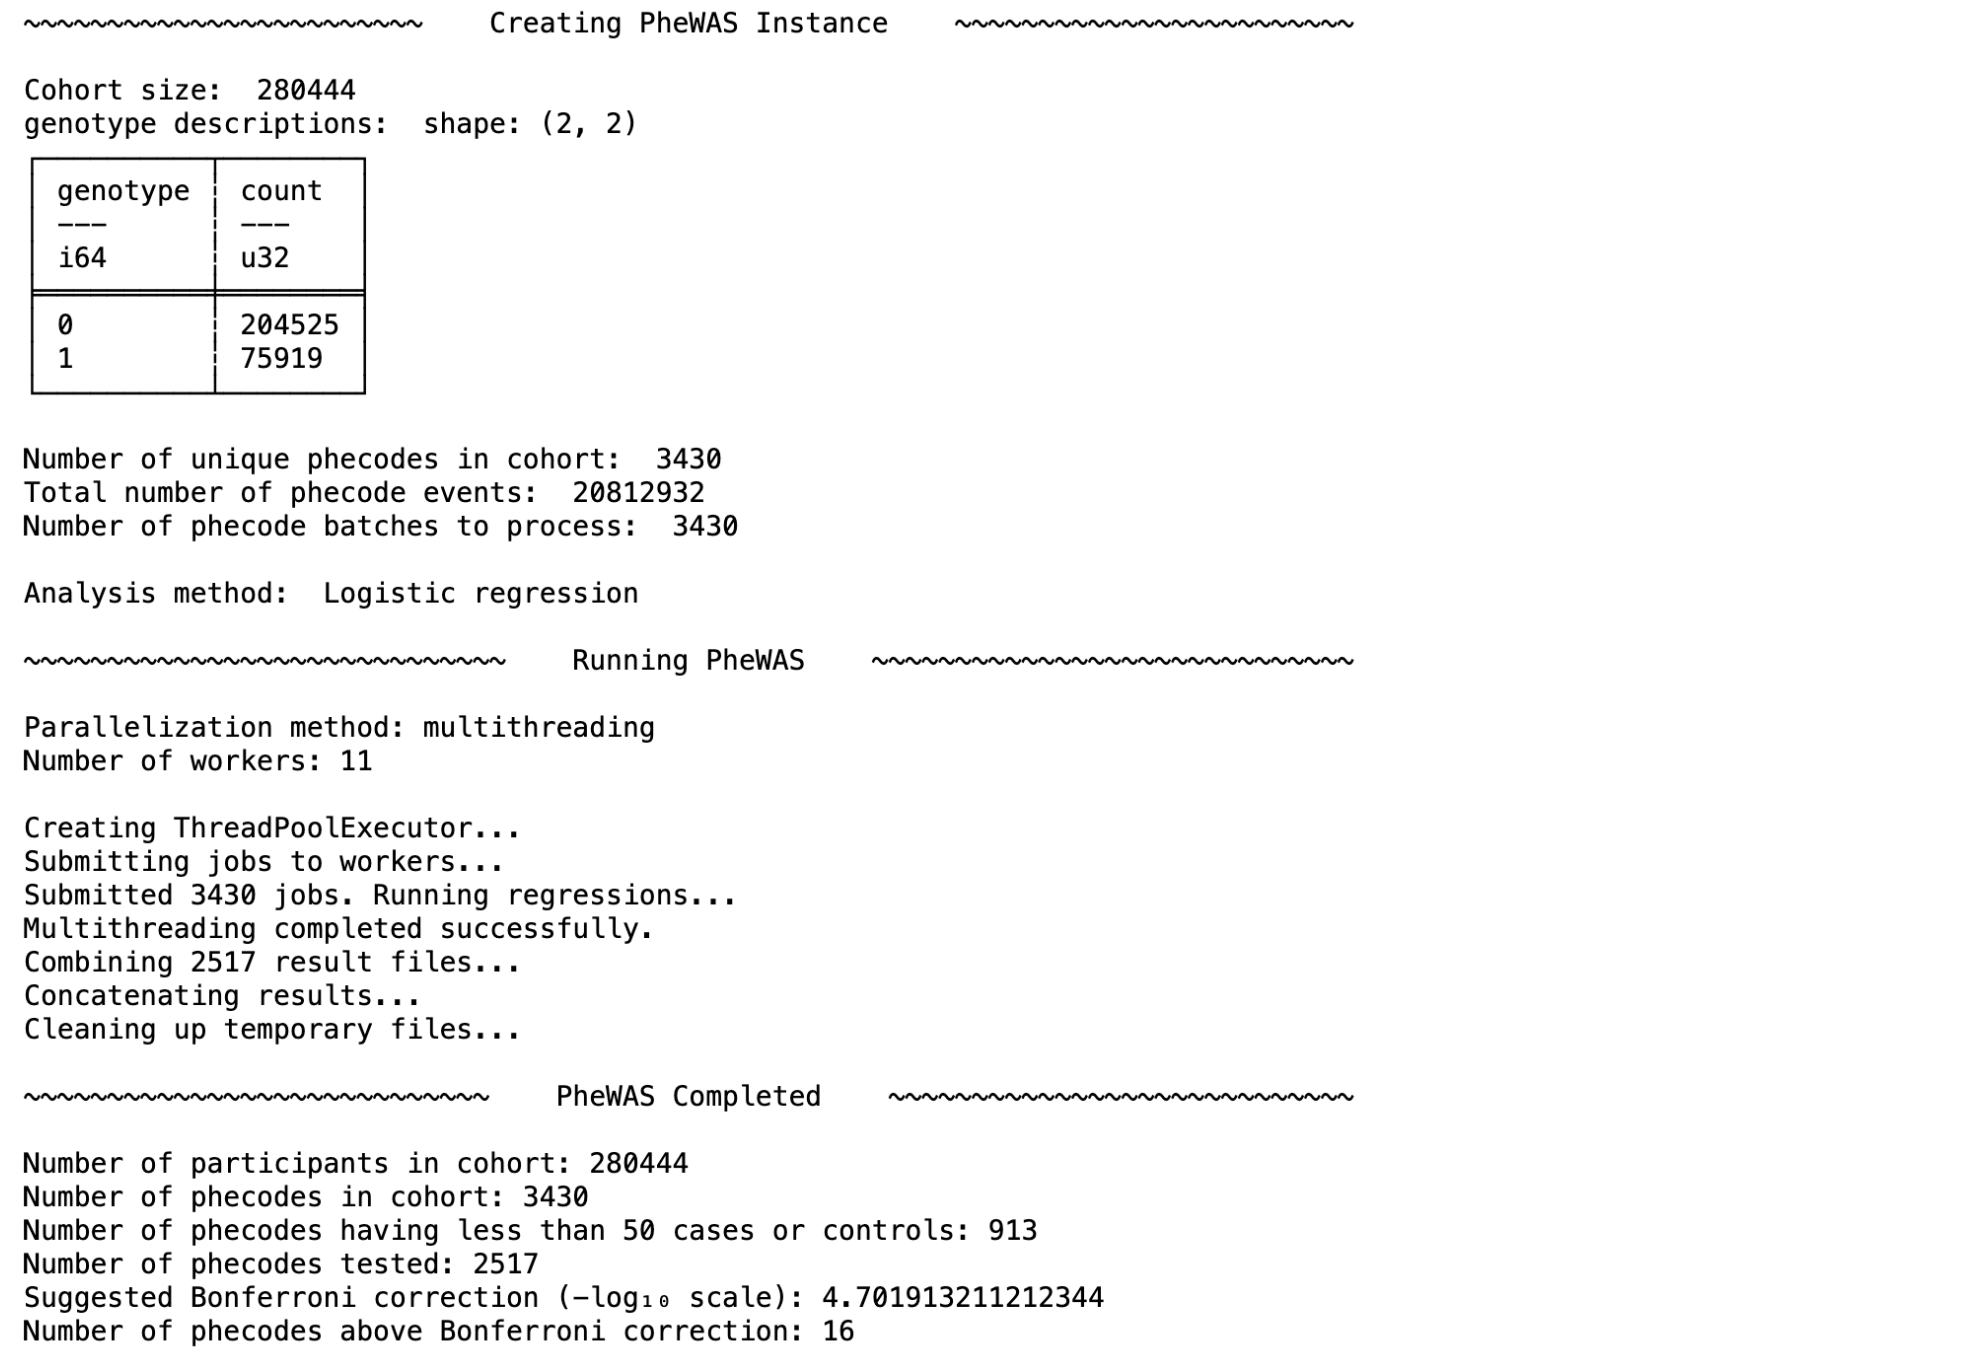

In [8]:
# If there was any error, the log below should contain some error details:
phewas.dsub.view_log(log_type="stderr", n_lines=100)

## Result visualization

In [9]:
# instantiate class Plot with PheWAS results as input
p = Plot(f"{bucket}/test/results/dsub__rs429358_phewas_results.tsv")

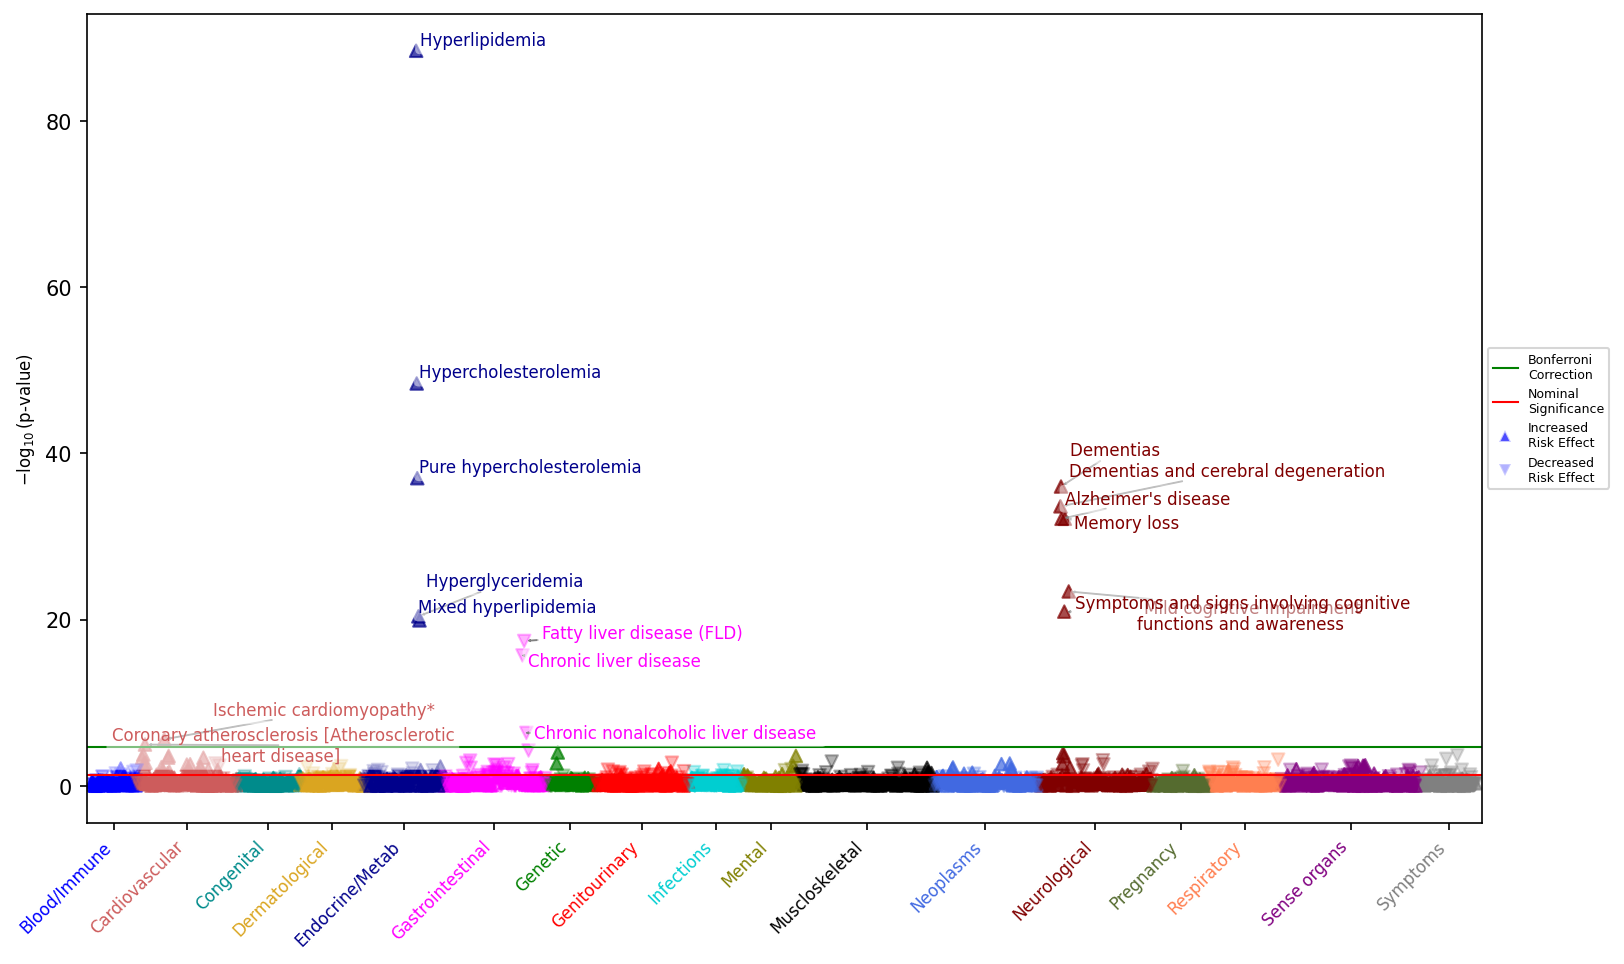

In [10]:
# generate Manhattan plot
p.manhattan(label_values="p_value", label_count=16, save_plot=False)

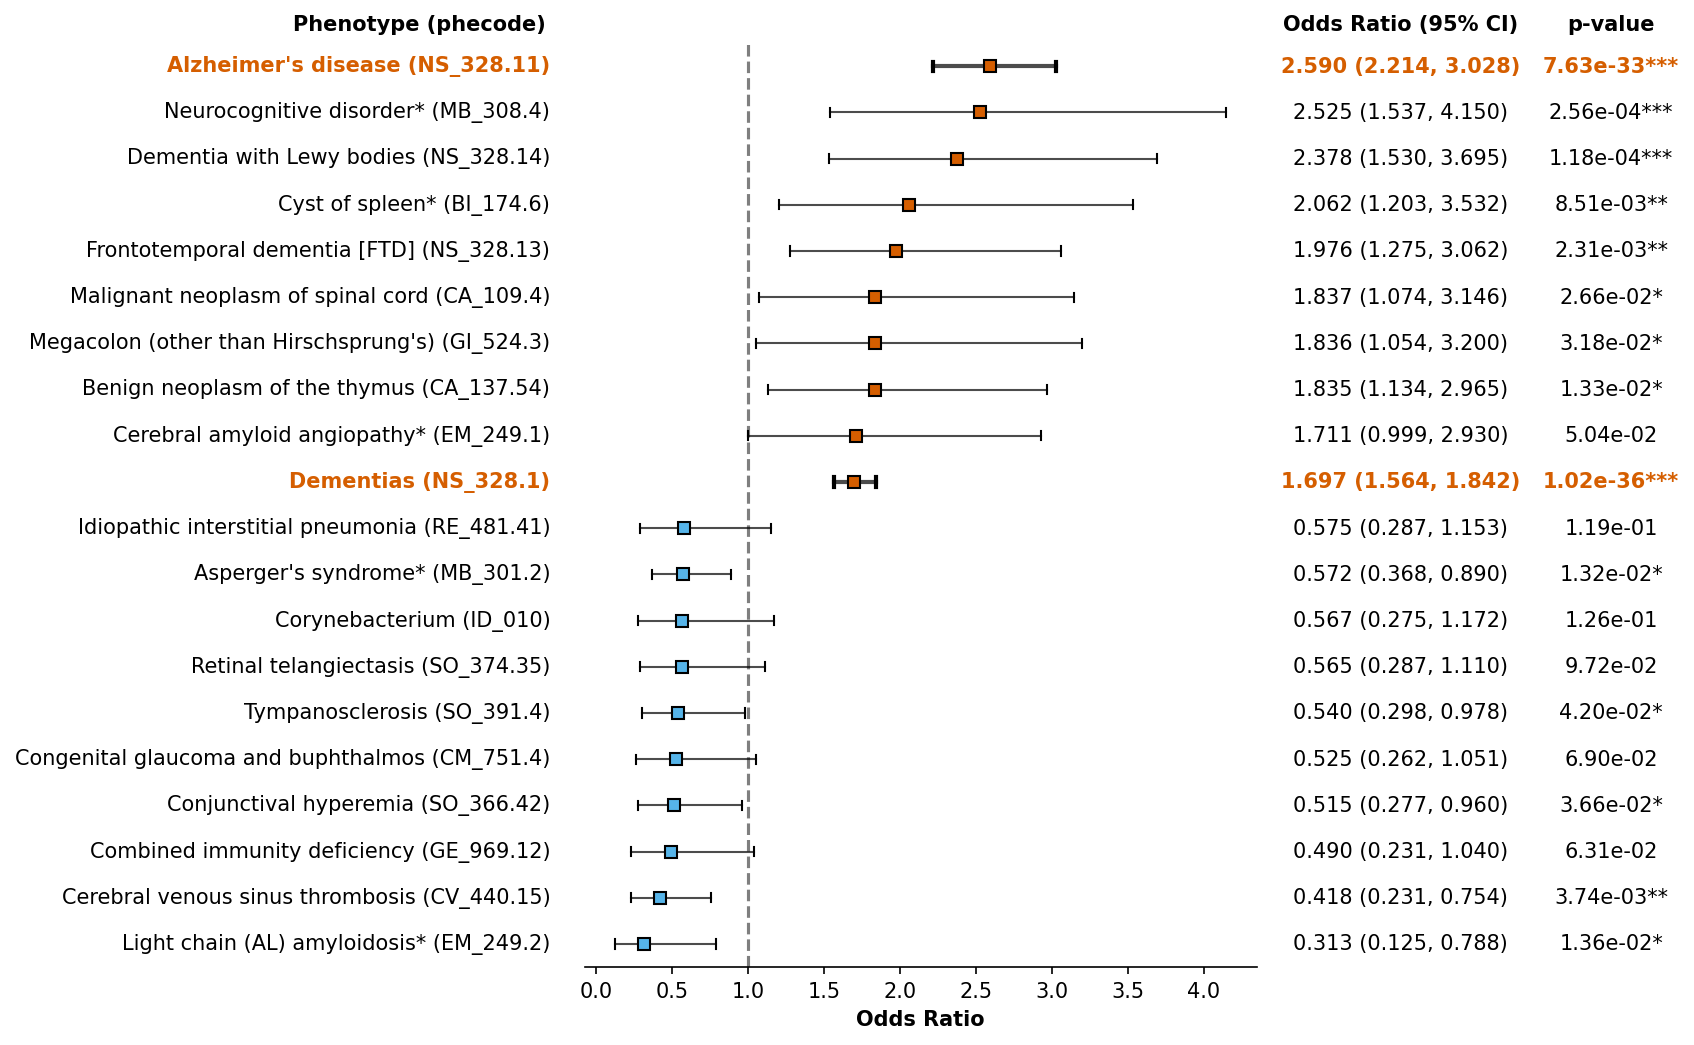

In [11]:
# generate forest plot; by default, it will show top 10 positive and negative phenotypes
p.forest(highlight_significance=True, show_p_value_asterisks=True, save_plot=False)